# 12. WaveNet GAN + Lambert W Gaussianization

Same **WaveNet-based GAN** architecture as NB07, but with the **QuantGAN-style 3-stage preprocessing**
pipeline from Wiese et al. (2020):

1. **StandardScaler** — center and normalize log returns
2. **Gaussianize** — Lambert W inverse transform to remove heavy tails (Goerg 2011, 2015)
3. **StandardScaler** — re-standardize the Gaussianized output

### Key difference from NB07
| Aspect | NB07 (WaveNet GAN) | NB12 (this notebook) |
|--------|-------------------|----------------------|
| Preprocessing | MinMaxScaler [0,1] | StandardScaler → Gaussianize → StandardScaler |
| Generator output | sigmoid (bounded) | **linear** (unbounded, like QuantGAN) |
| Data range | [0, 1] | ~N(0,1) (unbounded, standardized) |
| Tail handling | Tail quantile loss | Lambert W removes excess kurtosis + tail loss |
| Huber δ | 0.1 (for [0,1] scale) | **1.0** (for N(0,1) scale) |
| LAMBDA_RECON | 100 | **1** (rebalanced — raw Huber ~356× larger on N(0,1)) |

Everything else (WaveNet architecture, gated causal convolutions, moment loss,
adaptive LR scheduling) is identical to NB07 for a controlled comparison.

## 1. Setup & Imports

In [1]:
# Import libraries
import os
import site
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Suppress TF C++ info/warning spam (must be set BEFORE importing TF)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# XLA fix for pip-bundled CUDA toolkit
_cuda_nvcc_dir = os.path.join(
    site.getsitepackages()[0] if site.getsitepackages() else
    os.path.join(os.path.dirname(os.__file__), '..', 'site-packages'),
    'nvidia', 'cuda_nvcc'
)
os.environ['XLA_FLAGS'] = f'--xla_gpu_cuda_data_dir={_cuda_nvcc_dir}'

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Multiply, Add, Concatenate, Dense,
    Dropout, GaussianNoise, LayerNormalization,
    SpectralNormalization                    # ← conditional D regularization
)
from tensorflow.keras.models import Model, load_model

import sys
sys.path.append('..')
from utils.gaussianize import Gaussianize

# Set seeds
tf.random.set_seed(42)
np.random.seed(42)

# Suppress Python-level TF logs
tf.get_logger().setLevel('ERROR')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Data Loading & Lambert W Preprocessing

3-stage pipeline (from QuantGAN paper, Section 3):  
1. **StandardScaler** — center and normalize (needed for IGMM convergence)  
2. **Gaussianize** — Lambert W inverse transform to remove heavy tails  
3. **StandardScaler** — re-standardize the Gaussianized output → ~N(0,1)

Output is ~N(0,1) with range ~[-3.5, 3.5]. The generator uses **linear** output (like QuantGAN) to avoid
bound outputs to [-3, 3], covering 99.7% of the data range.

In [2]:
# Load SP500 data (same source as NB07)
data = pd.read_csv('../data/raw/sp500.csv', index_col='Date', parse_dates=True)
data = data.apply(pd.to_numeric, errors='coerce')

close_prices = data['Close']
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
log_returns_array = log_returns.values.reshape(-1, 1)

print(f"Raw log returns: {len(log_returns_array)} observations")
print(f"  Range: [{log_returns_array.min():.4f}, {log_returns_array.max():.4f}]")
print(f"  Mean:  {log_returns_array.mean():.6f}")
print(f"  Std:   {log_returns_array.std():.6f}")
print(f"  Kurtosis: {float(pd.Series(log_returns_array.ravel()).kurtosis()):.2f}")

Raw log returns: 6036 observations
  Range: [-0.1277, 0.1096]
  Mean:  0.000197
  Std:   0.012379
  Kurtosis: 10.28


In [3]:
# ── 3-stage preprocessing: StandardScaler → Gaussianize → StandardScaler ──
# (QuantGAN paper, Section 3 — no CDF stage)

# Stage 1: standardize (needed for IGMM convergence)
scaler1 = StandardScaler()
stage1 = scaler1.fit_transform(log_returns_array)

# Stage 2: Gaussianize (Lambert W inverse — remove heavy tails)
gaussianizer = Gaussianize(max_iter=100, tol=1e-6)
stage2 = gaussianizer.fit_transform(stage1)

# Stage 3: re-standardize → ~N(0,1)
scaler2 = StandardScaler()
log_returns_scaled = scaler2.fit_transform(stage2.reshape(-1, 1)).astype(np.float32)

print(f"Gaussianize delta: {gaussianizer.delta_[0]:.6f}")
print(f"After preprocessing (3-stage Lambert):")
print(f"  Range: [{log_returns_scaled.min():.4f}, {log_returns_scaled.max():.4f}]")
print(f"  Mean:  {log_returns_scaled.mean():.6f}, Std: {log_returns_scaled.std():.6f}")
print(f"  Kurtosis: {float(pd.Series(log_returns_scaled.ravel()).kurtosis()):.2f}")

# Verify round-trip (3-stage inverse: scaler2⁻¹ → gauss⁻¹ → scaler1⁻¹)
recovered = scaler1.inverse_transform(
    gaussianizer.inverse_transform(
        scaler2.inverse_transform(log_returns_scaled)
    ).reshape(-1, 1)
)
roundtrip_err = np.max(np.abs(recovered - log_returns_array))
print(f"  Round-trip max error: {roundtrip_err:.2e}")

Gaussianize delta: 1.712322
After preprocessing (3-stage Lambert):
  Range: [-2.9601, 2.8183]
  Mean:  0.000000, Std: 1.000000
  Kurtosis: -0.64
  Round-trip max error: 4.47e-08


In [4]:
# Create sequences (same windowing as NB07)
sequence_length = 24  # Match LSTM TimeGAN for fair comparison
sequences = []
for i in range(len(log_returns_scaled) - sequence_length):
    sequences.append(log_returns_scaled[i:i+sequence_length])

sequences = np.array(sequences, dtype=np.float32)
print(f"Data shape: {sequences.shape}")
print(f"Scaled range: [{sequences.min():.4f}, {sequences.max():.4f}]")

Data shape: (6012, 24, 1)
Scaled range: [-2.9601, 2.8183]


## 3. WaveNet Building Blocks

Identical to NB07 — gated causal convolutions with skip connections.

In [5]:
def _maybe_sn(layer, use_spectral_norm=False):
    """Wrap a layer with SpectralNormalization if requested."""
    return SpectralNormalization(layer) if use_spectral_norm else layer


def wavenet_residual_block(input_tensor, nfilt, dilation_rate, 
                           residual_noise_std=None, seed=None,
                           use_spectral_norm=False):
    """Gated causal convolution block with skip connection.
    
    The core building block: uses tanh * sigmoid gating (like the 
    original WaveNet paper) instead of plain activations.
    When use_spectral_norm=True, all Conv1D layers are wrapped with
    SpectralNormalization to constrain the Lipschitz constant.
    """
    x = input_tensor
    
    # Project to nfilt channels if needed
    if x.shape[-1] != nfilt:
        x = _maybe_sn(Conv1D(filters=nfilt, kernel_size=1, padding='same'), use_spectral_norm)(x)
    
    # Optional noise injection for regularization
    if residual_noise_std:
        x = GaussianNoise(stddev=residual_noise_std, seed=seed)(x)
    
    # Gated activation: tanh(conv) * sigmoid(conv)
    tanh_out = _maybe_sn(Conv1D(filters=nfilt, kernel_size=3, dilation_rate=dilation_rate,
                      padding='causal', activation='tanh'), use_spectral_norm)(x)
    sigm_out = _maybe_sn(Conv1D(filters=nfilt, kernel_size=3, dilation_rate=dilation_rate,
                      padding='causal', activation='sigmoid'), use_spectral_norm)(x)
    gated = Multiply()([tanh_out, sigm_out])
    
    # Skip and residual outputs
    skip_out = _maybe_sn(Conv1D(filters=nfilt, kernel_size=1, padding='same'), use_spectral_norm)(gated)
    residual = _maybe_sn(Conv1D(filters=nfilt, kernel_size=1, padding='same'), use_spectral_norm)(gated)
    residual_out = Add()([x, residual])
    
    return residual_out, skip_out


def wavenet_block(input_tensor, nfilt, dilation_rates=None,
                  residual_noise_std=None, seed=None,
                  use_spectral_norm=False):
    """Stack of dilated causal convolutions with exponentially increasing dilation."""
    if dilation_rates is None:
        dilation_rates = [1, 2, 4, 8, 16]
    
    skip_connections = []
    x = input_tensor
    for i, dilation in enumerate(dilation_rates):
        x, skip = wavenet_residual_block(
            x, nfilt, dilation,
            residual_noise_std=residual_noise_std,
            seed=(seed + i) if seed else None,
            use_spectral_norm=use_spectral_norm
        )
        skip_connections.append(skip)
    return Add()(skip_connections)


def deep_wavenet(input_tensor, nfilt, n_stacks=2,
                 residual_noise_std=None, seed=None,
                 use_spectral_norm=False):
    """Stack multiple WaveNet blocks for deeper temporal modeling."""
    x = input_tensor
    for i in range(n_stacks):
        x = wavenet_block(
            x, nfilt,
            residual_noise_std=residual_noise_std,
            seed=(seed + 100 + i) if seed else None,
            use_spectral_norm=use_spectral_norm
        )
    return x


print("WaveNet building blocks defined (with conditional SpectralNorm).")

WaveNet building blocks defined (with conditional SpectralNorm).


## 4. Build Generator and Discriminator

**Key change**: Generator output uses **linear** activation (like QuantGAN) since
Gaussianized data is ~N(0,1). 3×tanh saturated gradients and prevented tail exploration.
Linear output is unbounded, letting the generator reach the full distribution.

In [6]:
###############################################
# Generator — linear output for Gaussianized data (like QuantGAN)
###############################################
def build_wavenet_generator(sequence_length=24, feature_dim=1, latent_dim=32, nfilt=32,
                            n_stacks=2, latent_noise_std=0.01, 
                            residual_noise_std=0.01, seed=None):
    """WaveNet-based generator for unconditional financial time-series.
    
    Output activation: linear (unbounded, like QuantGAN).
    3×tanh saturates gradients and prevents exploring tails.
    NB07 uses sigmoid for MinMaxScaled [0,1] data.
    """
    
    latent_in = Input(shape=(sequence_length, latent_dim), name='latent_input')
    
    x = latent_in
    
    # Latent augmentation (from swim repo generator)
    if latent_noise_std:
        x = GaussianNoise(latent_noise_std, name='latent_noise',
                          seed=seed)(x)
    
    # Process through WaveNet
    x = deep_wavenet(x, nfilt, n_stacks=n_stacks,
                     residual_noise_std=residual_noise_std, seed=seed)
    
    # ▶ Linear output — unbounded, like QuantGAN (no activation saturation)
    # 3×tanh crushed gradients near ±3, preventing tail exploration
    output = Dense(feature_dim, name='generator_output')(x)
    
    model = Model(inputs=latent_in, outputs=output, name='WaveNet_Generator')
    return model


###############################################
# Discriminator — optionally with SpectralNormalization
def build_wavenet_discriminator(sequence_length=24, feature_dim=1, nfilt=32,
                                n_stacks=2, residual_noise_std=None,
                                dropout_rate=None, seed=None,
                                use_spectral_norm=False):
    """WaveNet-based discriminator for financial time-series.
    
    When use_spectral_norm=True, all Conv1D and Dense layers are wrapped
    with SpectralNormalization to constrain the discriminator's Lipschitz
    constant (improves training stability, matching NB07 spectral variant).
    """
    data_in = Input(shape=(sequence_length, feature_dim), name='data_input')
    
    x = deep_wavenet(data_in, nfilt, n_stacks=n_stacks,
                     residual_noise_std=residual_noise_std, seed=seed,
                     use_spectral_norm=use_spectral_norm)
    
    # Optional dropout
    if dropout_rate:
        x = Dropout(dropout_rate, seed=seed)(x)
    
    # Per-timestep real/fake output
    output = _maybe_sn(Dense(1, activation='sigmoid', name='real_fake_output'),
                       use_spectral_norm)(x)
    
    model = Model(inputs=data_in, outputs=output, name='WaveNet_Discriminator')
    return model


print("Generator (linear output) and Discriminator builders defined.")

Generator (linear output) and Discriminator builders defined.


## 5. Instantiate Models and Training Setup

In [7]:
# Hyperparameters (identical to NB07)
LATENT_DIM = 32        # Noise vector dimension per timestep
NFILT = 32             # WaveNet filter count
N_STACKS = 2           # Number of stacked WaveNet blocks
FEATURE_DIM = 1        # Single feature (log return)
SEQUENCE_LENGTH = 24   # Match LSTM TimeGAN

# ── Conditional SpectralNorm on discriminator ────────────────────
# Set to False to revert to the original (non-spectral) Lambert-GAN.
USE_SPECTRAL_NORM = True

LR_GENERATOR = 0.0002
LR_DISCRIMINATOR = 0.0001
BETA_1 = 0.5
BATCH_SIZE = 128
EPOCHS = 2000

# Build models
generator = build_wavenet_generator(
    sequence_length=SEQUENCE_LENGTH,
    feature_dim=FEATURE_DIM,
    latent_dim=LATENT_DIM,
    nfilt=NFILT,
    n_stacks=N_STACKS,
    latent_noise_std=0.01,
    residual_noise_std=0.01,
    seed=42
)

discriminator = build_wavenet_discriminator(
    sequence_length=SEQUENCE_LENGTH,
    feature_dim=FEATURE_DIM,
    nfilt=NFILT,
    n_stacks=N_STACKS,
    residual_noise_std=0.01,
    dropout_rate=0.1,
    seed=42,
    use_spectral_norm=USE_SPECTRAL_NORM
)

# Optimizers (same as NB07)
gen_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LR_GENERATOR, beta_1=BETA_1
)
disc_optimizer = tf.keras.optimizers.Adam(
    learning_rate=LR_DISCRIMINATOR, beta_1=BETA_1
)

generator.summary()
print()
discriminator.summary()

I0000 00:00:1773941707.681209 2929528 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1669 MB memory:  -> device: 0, name: Quadro P620, pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "WaveNet_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ latent_input        │ (None, 24, 32)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_noise        │ (None, 24, 32)    │          0 │ latent_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 24, 32)    │          0 │ latent_noise[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 32)    │      3,104 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 32)    │      3,104 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 24, 32)    │          0 │ conv1d[0][0],     │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 24, 32)    │      1,056 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 32)    │          0 │ gaussian_noise[0… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_1    │ (None, 24, 32)    │          0 │ add[0][0]         │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 24, 32)    │      3,104 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 24, 32)    │      3,104 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 24, 32)    │          0 │ conv1d_4[0][0],   │
│ (Multiply)          │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 24, 32)    │      1,056 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 32)    │          0 │ gaussian_noise_1… │
│                     │                   │            │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_2    │ (None, 24, 32)    │          0 │ add_1[0][0]       │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 24, 32)    │      3,104 │ gaussian_noise_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 24, 32)    │      3,104 │ gaussian_noise_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 24, 32)    │          0 │ conv1d_8[0][0],   │
│ (Multiply)          │                   │            │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 24, 32)    │      1,056 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 32)    │          0 │ gaussian_noise_2

 Total params: 81,121 (316.88 KB)

 Trainable params: 81,121 (316.88 KB)

...

Model: "WaveNet_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data_input          │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 24, 32)    │         96 │ data_input[0][0]  │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_10   │ (None, 24, 32)    │          0 │ spectral_normali… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 24, 32)    │      3,136 │ gaussian_noise_1… │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 24, 32)    │      3,136 │ gaussian_noise_1… │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 24, 32)    │          0 │ spectral_normali… │
│ (Multiply)          │                   │            │ spectral_normali… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 24, 32)    │      1,088 │ multiply_10[0][0] │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 24, 32)    │          0 │ gaussian_noise_1… │
│                     │                   │            │ spectral_normali… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_11   │ (None, 24, 32)    │          0 │ add_12[0][0]      │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 24, 32)    │      3,136 │ gaussian_noise_1… │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 24, 32)    │      3,136 │ gaussian_noise_1… │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_11         │ (None, 24, 32)    │          0 │ spectral_normali… │
│ (Multiply)          │                   │            │ spectral_normali… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 24, 32)    │      1,088 │ multiply_11[0][0] │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 24, 32)    │          0 │ gaussian_noise_1… │
│                     │                   │            │ spectral_normali… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_12   │ (None, 24, 32)    │          0 │ add_13[0][0]      │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 24, 32)    │      3,136 │ gaussian_noise_1… │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 24, 32)    │      3,136 │ gaussian_noise_1

 Total params: 82,434 (322.01 KB)

 Trainable params: 81,185 (317.13 KB)

 Non-trainable params: 1,249 (4.88 KB)

## 6. Training Loop

Same training procedure as NB07:  
- Adversarial + Huber reconstruction + moment matching + **tail quantile matching** loss  
- Huber δ=1.0 (calibrated for N(0,1) scale, not [0,1])  
- LAMBDA_RECON=1 (rebalanced — raw Huber errors ~356× larger on N(0,1); λ=10 caused 75% recon dominance)  
- Gradient clipping to [-1, 1]  
- Balanced adaptive LR scheduling  
- TensorBoard logging

In [8]:
import datetime
from utils.models_utils import (smooth_positive_labels, smooth_negative_labels,
                                BalancedAdaptiveLearningRateSchedule,
                                compute_moment_loss, compute_tail_loss)

# Loss functions
bce = tf.keras.losses.BinaryCrossentropy()
huber = tf.keras.losses.Huber(delta=0.5)  # δ=1.0 for N(0,1) scale (NB07 uses δ=0.1 for [0,1])

# Lambda weights — rebalanced for N(0,1) Gaussianized data
# Raw Huber errors are ~356× larger on N(0,1) vs [0,1] (0.712 vs 0.002)
# At λ=10, recon was 74.6% of G_total → center-pushing collapse
# At λ=1, effective recon ≈ 0.71, comparable to MinMax effective 0.20
LAMBDA_ADV = 1.0
LAMBDA_RECON = 1.0      # Was 10.0 — still caused 74.6% recon dominance (need ≤1)
LAMBDA_MOMENT = 5.0
LAMBDA_TAIL = 50.0      # Tail quantile matching (bottom/top 5%)

# Balanced Adaptive LR (same config as NB07)
adaptive_lr = BalancedAdaptiveLearningRateSchedule(
    initial_gen_lr=LR_GENERATOR,
    initial_disc_lr=LR_DISCRIMINATOR,
    adjustment_factor=1.1,
    tolerance=0.4,
    min_lr=3e-6,
    max_lr=5e-4,
    max_lr_ratio=5.0,
)
LR_ADJUST_EVERY = 50

# TensorBoard
log_dir = os.path.join('..', 'logs', 'wavenet_gan_lambert',
                       datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
tb_writer = tf.summary.create_file_writer(log_dir)
print(f"TensorBoard log dir: {log_dir}")
print(f"  → Launch: tensorboard --logdir {os.path.dirname(log_dir)}")


@tf.function
def train_step(real_data, batch_size):
    """Single training step with tail loss for Lambert-preprocessed data."""
    
    noise_gen = tf.random.normal(
        shape=(batch_size, SEQUENCE_LENGTH, LATENT_DIM), mean=0.0, stddev=1.0
    )
    noise_disc = tf.random.normal(
        shape=(batch_size, SEQUENCE_LENGTH, LATENT_DIM), mean=0.0, stddev=1.0
    )
    
    with tf.GradientTape() as disc_tape, tf.GradientTape() as gen_tape:
        fake_data_gen = generator(noise_gen, training=True)
        fake_data_disc = generator(noise_disc, training=True)
        
        real_output = discriminator(real_data, training=True)
        fake_output_disc = discriminator(fake_data_disc, training=True)
        fake_output_gen = discriminator(fake_data_gen, training=True)
        
        # Label smoothing
        real_labels = smooth_positive_labels(tf.ones_like(real_output))
        fake_labels = smooth_negative_labels(tf.zeros_like(fake_output_disc))
        
        # Discriminator loss
        d_loss_real = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(real_labels, real_output))
        d_loss_fake = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(fake_labels, fake_output_disc))
        total_disc_loss = d_loss_real + d_loss_fake
        
        # Generator losses
        gen_real_labels = smooth_positive_labels(tf.ones_like(fake_output_gen))
        g_loss_adv = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(gen_real_labels, fake_output_gen))
        
        # Huber reconstruction loss (δ=1.0 for N(0,1) scale)
        g_loss_recon = tf.reduce_mean(
            tf.keras.losses.huber(real_data, fake_data_gen, delta=0.5))
        
        # Moment matching loss (std + skewness + kurtosis)
        g_loss_moment = compute_moment_loss(real_data, fake_data_gen)
        
        # Tail quantile matching loss (bottom/top 5% — targets extreme values)
        g_loss_tail = compute_tail_loss(real_data, fake_data_gen, tail_pct=0.05)
        
        total_gen_loss = (LAMBDA_ADV * g_loss_adv
                          + LAMBDA_RECON * g_loss_recon
                          + LAMBDA_MOMENT * g_loss_moment
                          + LAMBDA_TAIL * g_loss_tail)
    
    disc_grads = disc_tape.gradient(total_disc_loss, discriminator.trainable_variables)
    gen_grads = gen_tape.gradient(total_gen_loss, generator.trainable_variables)
    
    disc_grads = [tf.clip_by_value(g, -1.0, 1.0) if g is not None else g 
                  for g in disc_grads]
    gen_grads = [tf.clip_by_value(g, -1.0, 1.0) if g is not None else g 
                 for g in gen_grads]
    
    disc_optimizer.apply_gradients(
        zip(disc_grads, discriminator.trainable_variables))
    gen_optimizer.apply_gradients(
        zip(gen_grads, generator.trainable_variables))
    
    return {
        'disc_loss': total_disc_loss,
        'gen_loss': total_gen_loss,
        'disc_real': d_loss_real,
        'disc_fake': d_loss_fake,
        'gen_adv': g_loss_adv,
        'gen_recon': g_loss_recon,
        'gen_moment': g_loss_moment,
        'gen_tail': g_loss_tail,
    }


print("Training step compiled.")

TensorBoard log dir: ../logs/wavenet_gan_lambert/20260319-113509
  → Launch: tensorboard --logdir ../logs/wavenet_gan_lambert
Training step compiled.


In [9]:
# ── Log hyperparameters to CSV before training ──
import datetime as _dt

_HPARAM_LOG = '../data/lambert_hyperparameter_log.csv'
_run_ts = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

_hparams = {
    'timestamp':        _run_ts,
    'epochs':           EPOCHS,
    'batch_size':       BATCH_SIZE,
    'sequence_length':  SEQUENCE_LENGTH,
    'latent_dim':       LATENT_DIM,
    'nfilt':            NFILT,
    'n_stacks':         N_STACKS,
    'lr_generator':     LR_GENERATOR,
    'lr_discriminator': LR_DISCRIMINATOR,
    'beta_1':           BETA_1,
    'lambda_adv':       LAMBDA_ADV,
    'lambda_recon':     LAMBDA_RECON,
    'lambda_moment':    LAMBDA_MOMENT,
    'lambda_tail':      LAMBDA_TAIL,
    'huber_delta':      0.5,  # matches delta=0.5 in Huber() above
    'lr_adjust_every':  LR_ADJUST_EVERY,
    'min_lr':           adaptive_lr.min_lr,
    'max_lr':           adaptive_lr.max_lr,
    'gen_output':       'linear',
    'preprocessing':    'StandardScaler→Gaussianize→StandardScaler',
    'gaussianize_delta': float(gaussianizer.delta_[0]),
}

_row = pd.DataFrame([_hparams])

# Append if file exists, otherwise create with header
if os.path.exists(_HPARAM_LOG):
    _row.to_csv(_HPARAM_LOG, mode='a', header=False, index=False)
else:
    _row.to_csv(_HPARAM_LOG, index=False)

_run_id = len(pd.read_csv(_HPARAM_LOG))
print(f"Run #{_run_id} logged → {_HPARAM_LOG}")
print(_row.to_string(index=False))

AttributeError: 'Huber' object has no attribute 'delta'

In [ ]:
# Create tf.data.Dataset for mini-batch training
dataset = tf.data.Dataset.from_tensor_slices(sequences)
dataset = dataset.shuffle(buffer_size=len(sequences), seed=42)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

# Training loop
print(f"Training WaveNet GAN (Lambert W) for {EPOCHS} epochs...")
print(f"Dataset: {len(sequences)} sequences, {len(sequences)//BATCH_SIZE} steps/epoch")
print(f"Generator LR: {LR_GENERATOR}, Discriminator LR: {LR_DISCRIMINATOR}")
print(f"Adaptive LR re-balance every {LR_ADJUST_EVERY} epochs")
print(f"Lambda: adv={LAMBDA_ADV}, recon={LAMBDA_RECON}, moment={LAMBDA_MOMENT}, tail={LAMBDA_TAIL}")
print(f"Preprocessing: StandardScaler → Gaussianize(δ={gaussianizer.delta_[0]:.4f}) → StandardScaler")
print(f"Generator output: linear (unbounded), Huber δ=1.0")
print("="*70)

history = {
    'disc_loss': [], 'gen_loss': [],
    'disc_real': [], 'disc_fake': [],
    'gen_adv': [], 'gen_recon': [], 'gen_moment': [], 'gen_tail': [],
    'lr_gen': [], 'lr_disc': []
}

for epoch in range(EPOCHS):
    epoch_metrics = {key: [] for key in history if key not in ('lr_gen', 'lr_disc')}
    
    for batch in dataset:
        batch_size = tf.shape(batch)[0]
        metrics = train_step(batch, batch_size)
        
        for key in epoch_metrics:
            epoch_metrics[key].append(metrics[key].numpy())
    
    for key in epoch_metrics:
        history[key].append(np.mean(epoch_metrics[key]))

    # Balanced Adaptive LR
    if (epoch + 1) % LR_ADJUST_EVERY == 0:
        new_gen_lr, new_disc_lr = adaptive_lr(
            history['disc_loss'][-1] / 2.0,
            history['gen_adv'][-1]
        )
        gen_optimizer.learning_rate.assign(new_gen_lr)
        disc_optimizer.learning_rate.assign(new_disc_lr)

    history['lr_gen'].append(float(gen_optimizer.learning_rate))
    history['lr_disc'].append(float(disc_optimizer.learning_rate))

    # TensorBoard
    with tb_writer.as_default():
        tf.summary.scalar('loss/disc_total', history['disc_loss'][-1], step=epoch)
        tf.summary.scalar('loss/disc_real', history['disc_real'][-1], step=epoch)
        tf.summary.scalar('loss/disc_fake', history['disc_fake'][-1], step=epoch)
        tf.summary.scalar('loss/gen_total', history['gen_loss'][-1], step=epoch)
        tf.summary.scalar('loss/gen_adversarial', history['gen_adv'][-1], step=epoch)
        tf.summary.scalar('loss/gen_reconstruction', history['gen_recon'][-1], step=epoch)
        tf.summary.scalar('loss/gen_moment', history['gen_moment'][-1], step=epoch)
        tf.summary.scalar('loss/gen_tail', history['gen_tail'][-1], step=epoch)
        tf.summary.scalar('lr/generator', history['lr_gen'][-1], step=epoch)
        tf.summary.scalar('lr/discriminator', history['lr_disc'][-1], step=epoch)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d}/{EPOCHS} | "
              f"D: {history['disc_loss'][-1]:.4f} "
              f"(r:{history['disc_real'][-1]:.3f} f:{history['disc_fake'][-1]:.3f}) | "
              f"G: {history['gen_loss'][-1]:.4f} "
              f"(adv:{history['gen_adv'][-1]:.3f} rec:{history['gen_recon'][-1]:.4f} "
              f"mom:{history['gen_moment'][-1]:.3f} tail:{history['gen_tail'][-1]:.4f}) | "
              f"LR {history['lr_gen'][-1]:.1e}/{history['lr_disc'][-1]:.1e}")

tb_writer.flush()
print("\nTraining completed!")

Training WaveNet GAN (Lambert W) for 2000 epochs...
Dataset: 6012 sequences, 46 steps/epoch
Generator LR: 0.0002, Discriminator LR: 0.0001
Adaptive LR re-balance every 50 epochs
Lambda: adv=1.0, recon=1.0, moment=1.0, tail=50.0
Preprocessing: StandardScaler → Gaussianize(δ=1.7123) → StandardScaler
Generator output: linear (unbounded), Huber δ=1.0
Epoch    0/2000 | D: 1.3741 (r:0.622 f:0.752) | G: 4.6809 (adv:0.639 rec:0.6822 mom:0.802 tail:0.0512) | LR 2.0e-04/1.0e-04
Current d_loss/g_loss ratio: 0.60
  → G losing: disc_lr ↑ 1.10e-04, gen_lr ↓ 1.82e-04
Current d_loss/g_loss ratio: 0.56
  → G losing: disc_lr ↑ 1.21e-04, gen_lr ↓ 1.65e-04
Epoch  100/2000 | D: 1.1298 (r:0.466 f:0.664) | G: 2.6045 (adv:1.019 rec:0.7320 mom:0.138 tail:0.0143) | LR 1.7e-04/1.2e-04
Current d_loss/g_loss ratio: 0.51
  → G losing: disc_lr ↑ 1.33e-04, gen_lr ↓ 1.50e-04
Current d_loss/g_loss ratio: 0.48
  → G losing: disc_lr ↑ 1.46e-04, gen_lr ↓ 1.37e-04
Epoch  200/2000 | D: 1.0699 (r:0.425 f:0.645) | G: 3.1175 (

## 7. Training Loss Curves

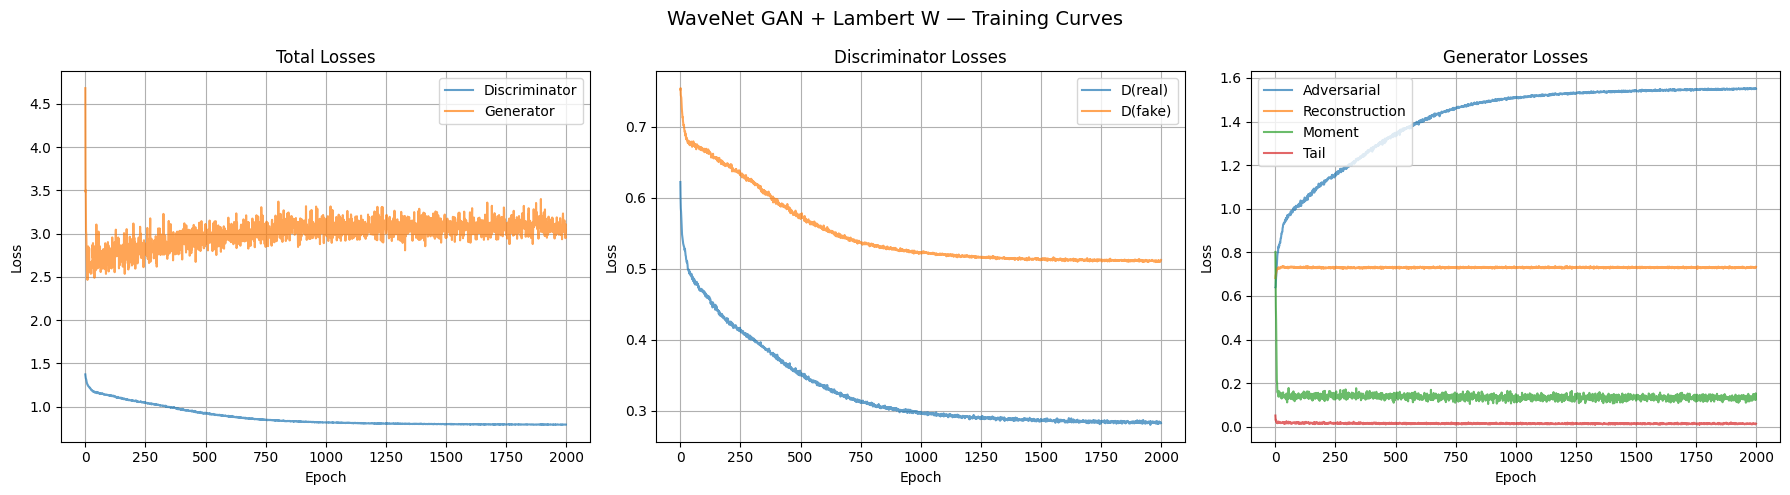

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total losses
axes[0].plot(history['disc_loss'], label='Discriminator', alpha=0.7)
axes[0].plot(history['gen_loss'], label='Generator', alpha=0.7)
axes[0].set_title('Total Losses')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Discriminator breakdown
axes[1].plot(history['disc_real'], label='D(real)', alpha=0.7)
axes[1].plot(history['disc_fake'], label='D(fake)', alpha=0.7)
axes[1].set_title('Discriminator Losses')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Generator breakdown
axes[2].plot(history['gen_adv'], label='Adversarial', alpha=0.7)
axes[2].plot(history['gen_recon'], label='Reconstruction', alpha=0.7)
axes[2].plot(history['gen_moment'], label='Moment', alpha=0.7)
axes[2].plot(history['gen_tail'], label='Tail', alpha=0.7)
axes[2].set_title('Generator Losses')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('WaveNet GAN + Lambert W — Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Generate Synthetic Data & Inverse Transform

In [ ]:
n_samples = 100

# Generate synthetic sequences in Gaussianized space
Z_synthetic = tf.random.normal(
    shape=(n_samples, SEQUENCE_LENGTH, LATENT_DIM), mean=0.0, stddev=1.0
)
synthetic_sequences = generator(Z_synthetic, training=False)
synthetic_gaussianized = synthetic_sequences.numpy()  # (n_samples, 24, 1)

print(f"Synthetic (Gaussianized space):")
print(f"  Range: [{synthetic_gaussianized.min():.4f}, {synthetic_gaussianized.max():.4f}]")
print(f"  Mean:  {synthetic_gaussianized.mean():.6f}")
print(f"  Std:   {synthetic_gaussianized.std():.6f}")

# ── Inverse preprocessing: StandardScaler⁻¹ → Gaussianize⁻¹ → StandardScaler⁻¹ ──
synth_flat = synthetic_gaussianized.reshape(-1, 1)

# Inverse stage 3 (StandardScaler)
inv3 = scaler2.inverse_transform(synth_flat)

# Inverse stage 2 (Gaussianize — re-add heavy tails)
inv2 = gaussianizer.inverse_transform(inv3.ravel()).reshape(-1, 1)

# Inverse stage 1 (StandardScaler → original log-return scale)
synthetic_rescaled = scaler1.inverse_transform(inv2).reshape(n_samples, SEQUENCE_LENGTH)

print(f"\nSynthetic (log-return space):")
print(f"  Range: [{synthetic_rescaled.min():.6f}, {synthetic_rescaled.max():.6f}]")
print(f"  Mean:  {synthetic_rescaled.mean():.6f}")
print(f"  Std:   {synthetic_rescaled.std():.6f}")
print(f"\nReal log returns:")
print(f"  Mean:  {log_returns.mean():.6f}")
print(f"  Std:   {log_returns.std():.6f}")

Synthetic (Gaussianized space):
  Range: [-3.1656, 2.7501]
  Mean:  0.003643
  Std:   0.994685

Synthetic (log-return space):
  Range: [-0.180675, 0.098182]
  Mean:  0.000288
  Std:   0.012964

Real log returns:
  Mean:  0.000197
  Std:   0.012380


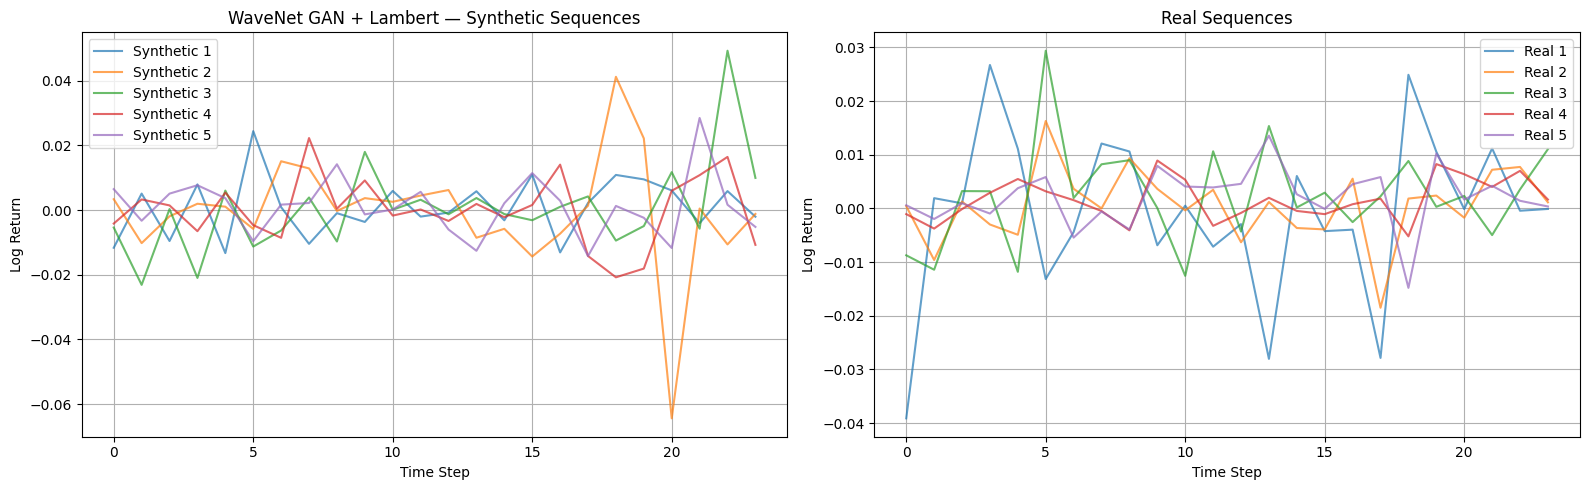

Synthetic stats — mean: 0.000288, std: 0.012964, min: -0.180675, max: 0.098182
Real stats     — mean: 0.000197, std: 0.012380, min: -0.127652, max: 0.109572


In [ ]:
# Plot synthetic vs real sequences
plot_idx = np.linspace(0, len(sequences) - 1, 5, dtype=int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Synthetic
for i in range(5):
    axes[0].plot(synthetic_rescaled[i], alpha=0.7, label=f'Synthetic {i+1}')
axes[0].set_title('WaveNet GAN + Lambert — Synthetic Sequences')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Log Return')
axes[0].legend()
axes[0].grid(True)

# Real (inverse-transform from Gaussianized sequences)
real_gauss = sequences[plot_idx].reshape(-1, 1)
real_inv3 = scaler2.inverse_transform(real_gauss)
real_inv2 = gaussianizer.inverse_transform(real_inv3.ravel()).reshape(-1, 1)
real_plot = scaler1.inverse_transform(real_inv2).reshape(5, SEQUENCE_LENGTH)
for i in range(5):
    axes[1].plot(real_plot[i], alpha=0.7, label=f'Real {i+1}')
axes[1].set_title('Real Sequences')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Log Return')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Synthetic stats — mean: {synthetic_rescaled.mean():.6f}, "
      f"std: {synthetic_rescaled.std():.6f}, "
      f"min: {synthetic_rescaled.min():.6f}, max: {synthetic_rescaled.max():.6f}")
print(f"Real stats     — mean: {log_returns.mean():.6f}, "
      f"std: {log_returns.std():.6f}, "
      f"min: {log_returns.min():.6f}, max: {log_returns.max():.6f}")

## 9. Save Models & Data

In [ ]:
_sn_tag = '_spec' if USE_SPECTRAL_NORM else ''

os.makedirs('../models', exist_ok=True)

generator.save(f'../models/wavenet_lambert{_sn_tag}_generator.keras')
discriminator.save(f'../models/wavenet_lambert{_sn_tag}_discriminator.keras')

generator.save_weights(f'../models/wavenet_lambert{_sn_tag}_generator.weights.h5')
discriminator.save_weights(f'../models/wavenet_lambert{_sn_tag}_discriminator.weights.h5')

# Save synthetic data in Gaussianized space (generator's native output)
np.save(f'../data/processed/synthetic_wavenet_lambert{_sn_tag}.npy', synthetic_sequences.numpy())

# Save raw log-return CSV
pd.DataFrame(
    synthetic_rescaled.flatten(), columns=['Synthetic_LogReturn']
).to_csv(f'../data/synthetic/wavenet_lambert{_sn_tag}_synthetic_full.csv', index=False)

print("Saved:")
print(f"  models/wavenet_lambert{_sn_tag}_generator.keras")
print(f"  models/wavenet_lambert{_sn_tag}_discriminator.keras")
print(f"  data/processed/synthetic_wavenet_lambert{_sn_tag}.npy — {synthetic_sequences.numpy().shape}")
print(f"  data/synthetic/wavenet_lambert{_sn_tag}_synthetic_full.csv")

Saved:
  models/wavenet_lambert_generator.keras
  models/wavenet_lambert_discriminator.keras
  data/processed/synthetic_wavenet_lambert.npy — (100, 24, 1)
  data/synthetic/wavenet_lambert_synthetic_full.csv
